In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp
import csv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Usaré la carpeta: /content/drive/MyDrive/datostallerdistancias


/tmp/ipython-input-3745985621.py:72: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Fecha-Hora"] = pd.to_datetime(df["Fecha-Hora"], errors="coerce")


Processing file: /content/drive/MyDrive/datostallerdistancias/mediciones_clg_normalsup_pm25_a_2018-11-01T00_00_00_2018-11-30T23_59_59.csv
  Header detectado: ['fecha_hora_med', 'id_parametro', 'valor'] | sep: ','
Processing file: /content/drive/MyDrive/datostallerdistancias/mediciones_clg_normalsup_pm25_a_2018-12-01T00_00_00_2018-12-31T23_59_59.csv
  Header detectado: ['fecha_hora_med', 'id_parametro', 'valor'] | sep: ','
Processing file: /content/drive/MyDrive/datostallerdistancias/mediciones_clg_normalsup_pm25_a_2019-01-01T00_00_00_2019-01-31T23_59_59.csv
  → sin datos, se omite
Processing file: /content/drive/MyDrive/datostallerdistancias/mediciones_clg_normalsup_pm25_a_2019-02-01T00_00_00_2019-02-28T23_59_59.csv
  → sin datos, se omite
Processing file: /content/drive/MyDrive/datostallerdistancias/mediciones_clg_normalsup_pm25_a_2019-03-01T00_00_00_2019-03-31T23_59_59.csv
  → sin datos, se omite
Processing file: /content/drive/MyDrive/datostallerdistancias/mediciones_clg_normalsup_p

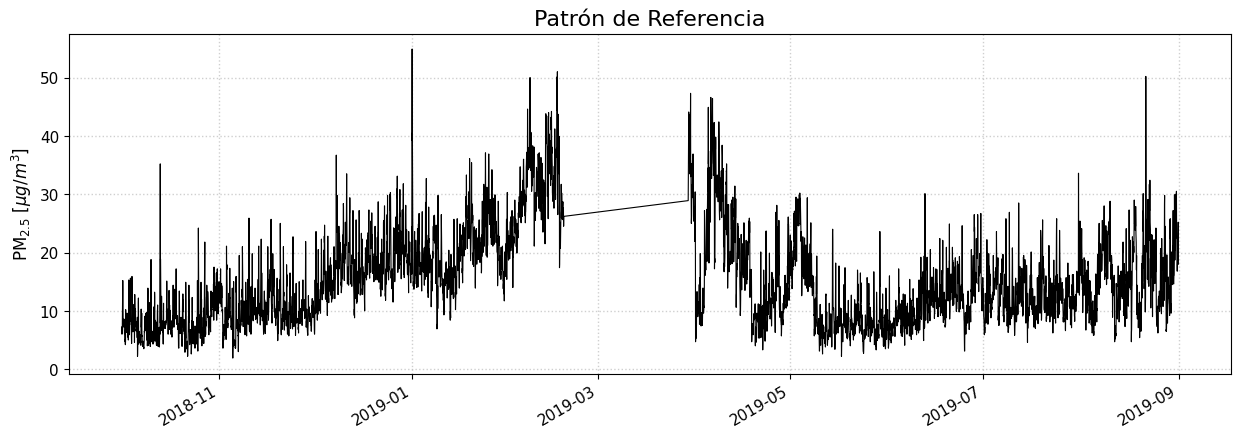

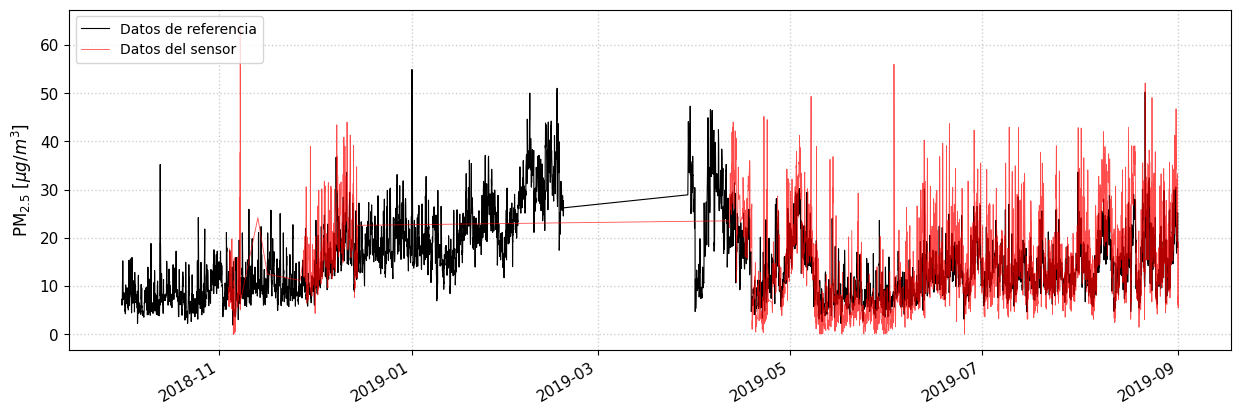

TZ df: None | TZ gf: None
Filas solapadas en data: 3326
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3326 entries, 2019-04-11 17:00:00 to 2019-08-31 23:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ref     3326 non-null   float64
 1   sen     3326 non-null   float64
dtypes: float64(2)
memory usage: 78.0 KB
None
Coeficientes  : [6.94 0.41]
Sigma coefic. : [0.13 0.01]
RMSE = 4.07  | MAE = 3.01  | R² = 0.48


/tmp/ipython-input-3745985621.py:192: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ref = df[["PM25_REF"]].resample("1H", label="left", closed="left").mean().rename(columns={"PM25_REF":"PM25_REF_H"})
/tmp/ipython-input-3745985621.py:193: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sen = gf[["PM25_IOT"]].resample("1H", label="left", closed="left").mean().rename(columns={"PM25_IOT":"PM25_IOT_H"})


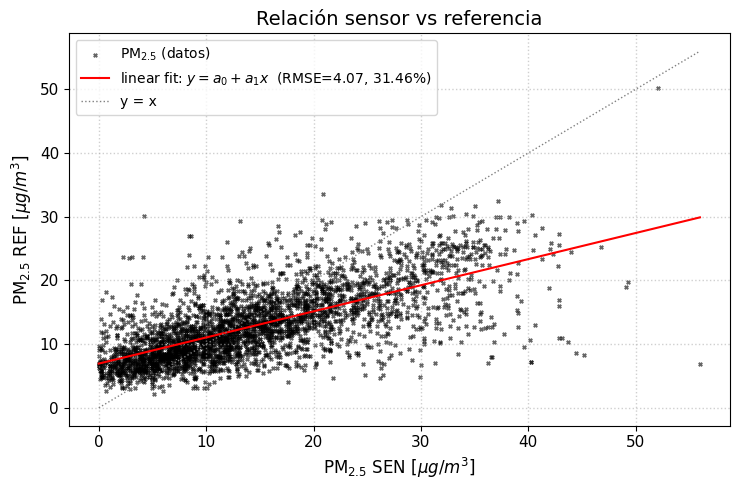

Coeficientes: a0=6.941, a1=0.410
MAE=3.01   RMSE=4.07   R^2=0.475   RMSE%(media)=31.46%


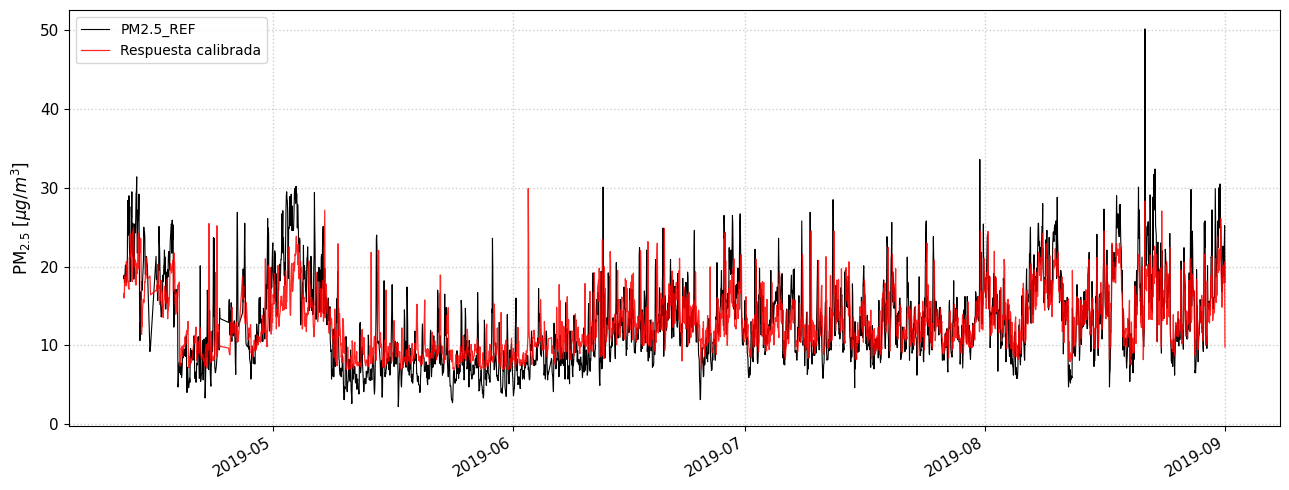

Cobertura dentro de ±5.0 µg/m³: 82.5%
Tramo contiguo más largo: 2019-08-14 09:00 → 2019-08-17 22:00 (3 days 13:00:00)


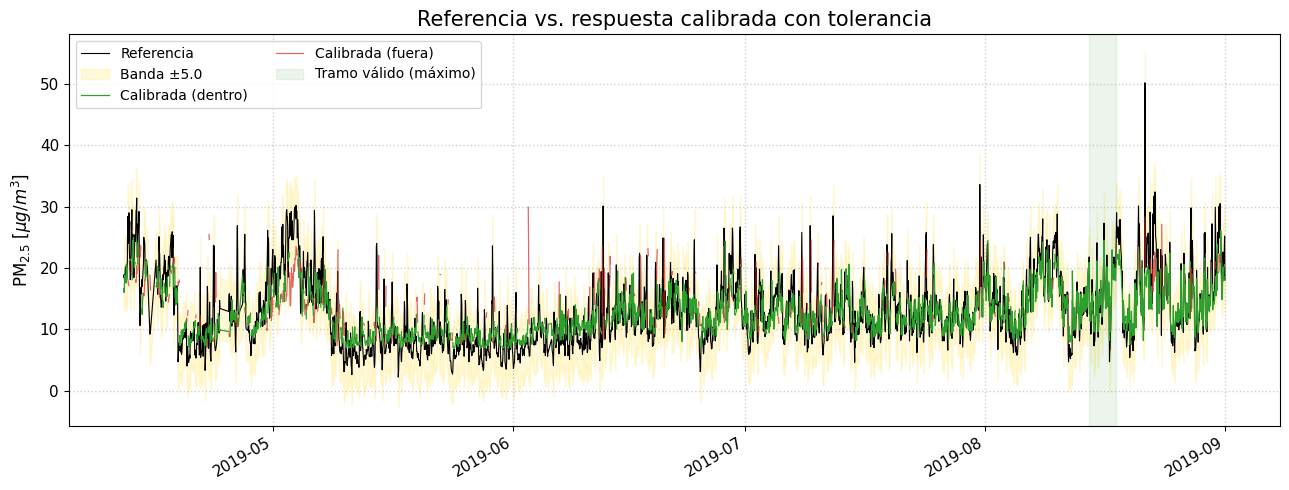

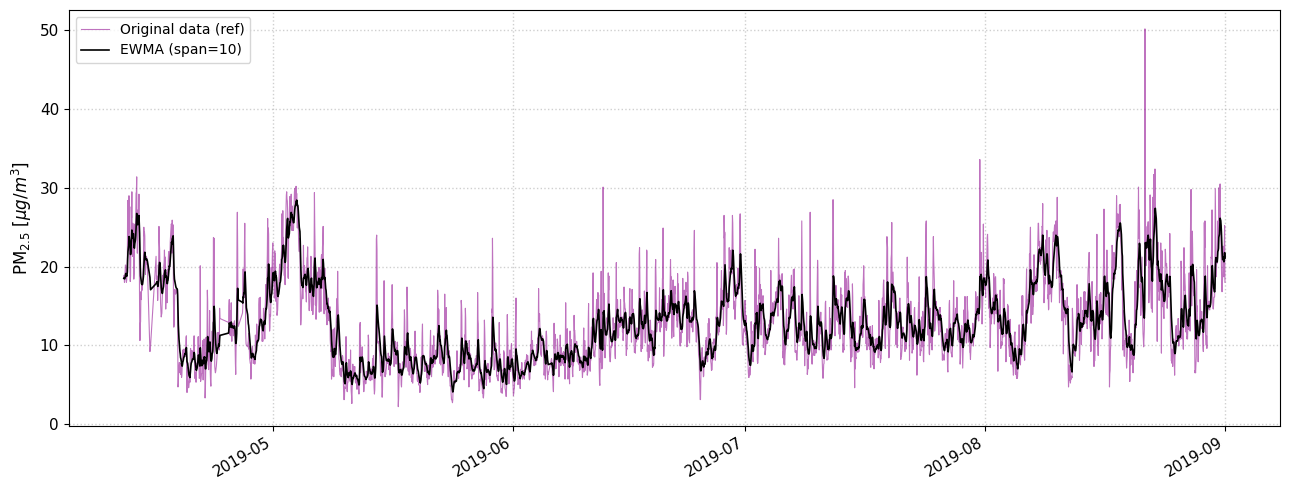

Coeficientes  : [4.81 0.56]
Sigma coefic. : [0.11 0.01]
RMSE = 2.38  | MAE = 1.81  | R² = 0.79
TRAIN → MAE=1.81  RMSE=2.38  R²=0.790
VALID → MAE=1.21  RMSE=1.55  R²=0.841
Archivos guardados en: /content/drive/MyDrive/datostallerdistancias/salidas


In [ ]:
# ============================================================
# Calibración PM2.5 en Google Colab (con Drive)
# Lee: "Datos Estaciones AMB.xlsx" (hoja 'Normal') y mediciones (xlsx o CSV)
# Crea: ref/sen horarios, ajusta modelo lineal, métricas y gráficas
# ============================================================

# 0) Montar Drive y localizar carpeta
from google.colab import drive
drive.mount('/content/drive')

import os, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.optimize import curve_fit

# --- Configura el nombre de tu carpeta en Mi unidad:
FOLDER_NAME = 'datostallerdistancias'   # cámbialo si tu carpeta se llama distinto

# Busca automáticamente la carpeta en Mi unidad (recursivo)
candidates = glob.glob(f'/content/drive/MyDrive/**/{FOLDER_NAME}', recursive=True)
assert candidates, f'No encontré la carpeta "{FOLDER_NAME}" en tu Drive.'
BASE_DIR = candidates[0]
print('Usaré la carpeta:', BASE_DIR)

# 1) Utilidades
def _find(colnames, candidates):
    #Devuelve el primer nombre real de columna que coincida con la lista candidates (case/espacios/acentos tolerantes).
    norm = lambda s: ''.join(ch for ch in str(s).lower() if ch.isalnum())
    # Modify to clean column names before creating the index
    idx  = {norm(c.replace('"', '').replace("'", "")): c for c in colnames}
    for cand in candidates:
        k = norm(cand)
        # Modified to handle extra characters in column names
        for col_k in idx:
            if k in col_k:
                return idx[col_k]
    return None

def style(ax=None, xlabel=None,
          ylabel=r"$\mathrm{PM}_{2.5}$ [$\mu g / m^3$]",
          fontsize=12, grid=True, time_axis=False, date_fmt="%Y-%m"):
    if ax is None:
        ax = plt.gca()
    ax.set_xlabel("" if xlabel is None else xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize-1)
    if grid:
        ax.grid(True, linestyle=":", linewidth=1.0, alpha=0.6)
    if time_axis:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(30); lbl.set_horizontalalignment("right")
    return ax

# 2) Cargar REFERENCIA (Excel)
ref_xlsx = os.path.join(BASE_DIR, 'Datos Estaciones AMB.xlsx')
assert os.path.exists(ref_xlsx), f'No existe: {ref_xlsx}'

# intenta leer la hoja 'Normal', si no existe toma la primera
try:
    df_raw = pd.read_excel(ref_xlsx, sheet_name='Normal')
except Exception:
    df_raw = pd.read_excel(ref_xlsx, sheet_name=0)

ref_date = _find(df_raw.columns, ["Date&Time","Fecha-Hora","fecha_hora","datetime"])
ref_val  = _find(df_raw.columns, ["PM2.5","PM25"])
assert ref_date and ref_val, f"Referencia: no encuentro columnas de fecha/PM. Cols: {list(df_raw.columns)}"

df = df_raw[[ref_date, ref_val]].rename(columns={ref_date:"Fecha-Hora", ref_val:"PM25_REF"})
df["Fecha-Hora"] = pd.to_datetime(df["Fecha-Hora"], errors="coerce")
df["PM25_REF"]   = pd.to_numeric(df["PM25_REF"], errors="coerce")
df = df.dropna(subset=["Fecha-Hora","PM25_REF"]).set_index("Fecha-Hora").sort_index()

# 3) Cargar SENSOR (xlsx o CSV)
# 3) Cargar SENSOR (xlsx o CSV) — robusto por encabezados con comillas/comas
import csv

sen_xlsx = os.path.join(BASE_DIR, 'Mediciones.xlsx')
if os.path.exists(sen_xlsx):
    gf_raw = pd.read_excel(sen_xlsx)
else:
    csvs = sorted(glob.glob(os.path.join(BASE_DIR, 'mediciones*.csv')))
    assert csvs, "No encontré 'Mediciones.xlsx' ni CSVs 'mediciones*.csv' en la carpeta."

    # candidatos de nombre
    fecha_cands = ['fecha_hora_med','fecha-hora','fecha_hora','date&time','fecha']
    valor_cands = ['valor','pm2.5','pm25']

    def _norm(s):  # normaliza para comparar
        return ''.join(ch for ch in str(s).lower() if ch.isalnum())

    gfs = []
    for p in csvs:
        print(f"Processing file: {p}")

        # 1) Lee el header crudo (primera línea no vacía)
        with open(p, 'r', encoding='latin-1', errors='ignore') as f:
            header_line = ''
            for line in f:
                if line.strip():
                    header_line = line.strip()
                    break

        header_clean = header_line.replace('\ufeff', '').strip()
        # -- no hay datos --
        if header_clean.lower().startswith('-- no hay datos'):
            print("  → sin datos, se omite")
            continue

        # 2) Detecta separador: si hay >=2 comas, usa ',', si no ';'
        sep = ',' if header_clean.count(',') >= 2 else ';'
        cols_raw = [c.strip().strip('"').strip("'") for c in header_clean.split(sep)]
        print("  Header detectado:", cols_raw, "| sep:", repr(sep))

        # 3) Intenta leer datos con ese header
        try:
            tmp = pd.read_csv(
                p, sep=sep, decimal=',', engine='python',
                header=None, names=cols_raw, skiprows=1,
                quoting=csv.QUOTE_MINIMAL, on_bad_lines='skip',
                encoding='latin-1'
            )
        except Exception:
            # Fallback: sin tratamiento de comillas
            tmp = pd.read_csv(
                p, sep=sep, decimal=',', engine='python',
                header=None, names=cols_raw, skiprows=1,
                quoting=csv.QUOTE_NONE, escapechar='\\',
                on_bad_lines='skip', encoding='latin-1'
            )

        # 4) Encuentra columnas por NOMBRE (no por índice)
        low = {c.lower(): c for c in tmp.columns}

        date_col = None
        for cand in fecha_cands:
            if cand in low:
                date_col = low[cand]; break

        value_col = None
        for cand in valor_cands:
            if cand in low:
                value_col = low[cand]; break

        if date_col is None or value_col is None:
            print("  → columnas esperadas no encontradas, se omite")
            continue

        d = tmp[[date_col, value_col]].copy()
        d.columns = ['Fecha-Hora', 'PM25_IOT']
        gfs.append(d)

    assert gfs, "No se pudo construir el sensor desde los CSV."
    gf_raw = pd.concat(gfs, ignore_index=True)

# Normaliza tipos e índice
gf_raw['Fecha-Hora'] = pd.to_datetime(gf_raw['Fecha-Hora'], errors='coerce')
gf_raw['PM25_IOT']   = pd.to_numeric(gf_raw['PM25_IOT'], errors='coerce')
gf = gf_raw.dropna(subset=['Fecha-Hora','PM25_IOT']).set_index('Fecha-Hora').sort_index()

print("gf listo:", gf.shape, list(gf.columns))
print(gf.head())

# 4) Gráficas iniciales
plt.figure(figsize=(15,5))
plt.title("Patrón de Referencia", fontsize=16)
df["PM25_REF"].plot(color="k", lw=0.8)
style(); plt.show()

plt.figure(figsize=(15,5))
df["PM25_REF"].plot(color="k", label="Datos de referencia", lw=0.8)
gf["PM25_IOT"].plot(color="red", alpha=0.7, label="Datos del sensor", lw=0.6)
style(); plt.legend(loc="upper left"); plt.show()
# --- 4.5) Unificar zona horaria para evitar "tz-naive vs tz-aware" ---

def strip_tz_index(frame: pd.DataFrame) -> pd.DataFrame:
    """Si el índice tiene tz, lo convierte a UTC y luego quita la tz (naive)."""
    if isinstance(frame.index, pd.DatetimeIndex) and frame.index.tz is not None:
        frame = frame.tz_convert('UTC')          # normaliza a UTC
        frame.index = frame.index.tz_localize(None)  # quita tz (naive)
    return frame

# Aplica a referencia y sensor
df = strip_tz_index(df)
gf = strip_tz_index(gf)

print("TZ df:", df.index.tz, "| TZ gf:", gf.index.tz)  # ambos deben imprimir None

# 5) Resampleo horario
ref = df[["PM25_REF"]].resample("1H", label="left", closed="left").mean().rename(columns={"PM25_REF":"PM25_REF_H"})
sen = gf[["PM25_IOT"]].resample("1H", label="left", closed="left").mean().rename(columns={"PM25_IOT":"PM25_IOT_H"})

# 6) DATA alineada (desde 2019-03)
data = pd.concat([ref["PM25_REF_H"], sen["PM25_IOT_H"]], axis=1).rename(columns={"PM25_REF_H":"ref","PM25_IOT_H":"sen"}).dropna()
data = data.loc["2019-03":]
print("Filas solapadas en data:", len(data))
print(data.info())

# 7) Funciones métricas y ajuste
def D(y, y_):
    y  = np.asarray(y, dtype=float); y_ = np.asarray(y_, dtype=float)
    return float(np.sqrt(np.sum((y - y_)**2)))

def rmse(y, y_):
    y  = np.asarray(y, dtype=float); y_ = np.asarray(y_, dtype=float)
    n = len(y);  return float(D(y, y_) / np.sqrt(n)) if n else np.nan

def mae(y, y_):
    y  = np.asarray(y, dtype=float); y_ = np.asarray(y_, dtype=float)
    return float(np.mean(np.abs(y - y_))) if len(y) else np.nan

def r2(y, y_):
    y  = np.asarray(y, dtype=float); y_ = np.asarray(y_, dtype=float)
    ss_res = np.sum((y - y_)**2); ss_tot = np.sum((y - np.mean(y))**2)
    return float(1 - ss_res/ss_tot) if ss_tot>0 else np.nan

def linear(x, a0, a1): return a0 + a1*np.asarray(x, dtype=float)

def fit(func, xdata, ydata, r=2, pop=False, imp=True):
    x = np.asarray(xdata, dtype=float); y = np.asarray(ydata, dtype=float)
    popt, pcov = curve_fit(func, x, y, maxfev=10000)
    yhat = func(x, *popt)
    E = rmse(y, yhat)
    if imp:
        print("Coeficientes  :", np.round(popt, r))
        print("Sigma coefic. :", np.round(np.sqrt(np.diag(pcov)), r))
        print(f"RMSE = {E:.{r}f}  | MAE = {mae(y,yhat):.{r}f}  | R² = {r2(y,yhat):.{r}f}")
    xfit = np.linspace(x.min(), x.max(), 200)
    if pop: return popt
    return xfit, func(xfit, *popt)

# 8) Ajuste lineal y dispersión
a0, a1 = fit(linear, data["sen"], data["ref"], pop=True)
xx = np.linspace(data["sen"].min(), data["sen"].max(), 200)
yy = linear(xx, a0, a1)
yhat = linear(data["sen"], a0, a1)
yhat = pd.Series(linear(data["sen"], a0, a1), index=data.index, name='yhat')  # ✅ Series alineada

RMSE, MAE, R2 = rmse(data["ref"], yhat), mae(data["ref"], yhat), r2(data["ref"], yhat)
eps_m = 100*RMSE/np.mean(data["ref"])

fig, ax = plt.subplots(figsize=(7.5,5))
ax.scatter(data["sen"], data["ref"], s=6, marker="x", color="k", alpha=0.6, label=r"$\mathrm{PM}_{2.5}$ (datos)")
ax.plot(xx, yy, "r", label=fr"linear fit: $y=a_0+a_1x$  (RMSE={RMSE:.2f}, {eps_m:.2f}%)")
mmax = float(max(data['sen'].max(), data['ref'].max()))
ax.plot([0,mmax],[0,mmax], ls=":", lw=1, color="gray", label="y = x")
ax.set_title("Relación sensor vs referencia", fontsize=14)
style(ax, xlabel=r"$\mathrm{PM}_{2.5}$ SEN [$\mu g / m^3$]", ylabel=r"$\mathrm{PM}_{2.5}$ REF [$\mu g / m^3$]")
_ = ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

print(f"Coeficientes: a0={a0:.3f}, a1={a1:.3f}")
print(f"MAE={MAE:.2f}   RMSE={RMSE:.2f}   R^2={R2:.3f}   RMSE%(media)={eps_m:.2f}%")

# 9) Serie temporal: referencia vs calibrada
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(data.index, data['ref'], color='k', lw=0.8, label='PM2.5_REF')
ax.plot(data.index, yhat,      color='red', alpha=0.85, lw=0.9, label='Respuesta calibrada')
style(ax, time_axis=True)
_ = ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

# 10) Tolerancia y alcance (±TOL)
TOL = 5.0
resid = data['ref'] - yhat
mask_valid = resid.abs() <= TOL
coverage = 100.0 * mask_valid.mean()

g = (mask_valid != mask_valid.shift()).cumsum()
segments = data.groupby(g).apply(lambda seg: pd.Series({
    'valid': bool(mask_valid.loc[seg.index[0]]),
    'start': seg.index[0], 'end': seg.index[-1], 'n': len(seg)}))
valid_segs = segments[segments['valid']]
if not valid_segs.empty:
    best = valid_segs.sort_values('n', ascending=False).iloc[0]
    start_valid, end_valid = best['start'], best['end']
    duration = end_valid - start_valid
else:
    start_valid = end_valid = None
    duration = pd.Timedelta(0)

print(f"Cobertura dentro de ±{TOL} µg/m³: {coverage:.1f}%")
if start_valid is not None:
    print(f"Tramo contiguo más largo: {start_valid:%Y-%m-%d %H:%M} → {end_valid:%Y-%m-%d %H:%M} ({duration})")
else:
    print("No hay tramos dentro de tolerancia.")

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(data.index, data['ref'], color='k', lw=0.8, label='Referencia')
ax.fill_between(data.index, data['ref']-TOL, data['ref']+TOL, color='gold', alpha=0.15, label=fr'Banda ±{TOL}')
yhat_valid = yhat.where(mask_valid); yhat_out = yhat.where(~mask_valid)
ax.plot(data.index, yhat_valid, color='tab:green', lw=0.9, label='Calibrada (dentro)')
ax.plot(data.index, yhat_out,   color='tab:red',   lw=0.9, alpha=0.7, label='Calibrada (fuera)')
if start_valid is not None:
    ax.axvspan(start_valid, end_valid, color='green', alpha=0.08, label='Tramo válido (máximo)')
ax.set_title("Referencia vs. respuesta calibrada con tolerancia", fontsize=15, pad=6)
style(ax, time_axis=True); _ = ax.legend(loc='upper left', ncol=2)
plt.tight_layout(); plt.show()

# 11) Suavizado exponencial (EWMA) y split train/valid
sm = 10
smot = data.ewm(span=sm, adjust=False).mean()

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(data.index, data['ref'], color='darkmagenta', alpha=0.55, lw=0.8, label='Original data (ref)')
ax.plot(smot.index, smot['ref'], color='k', lw=1.2, label=f"EWMA (span={sm})")
style(ax, time_axis=True); _ = ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

m = 2
span = smot.index.max() - smot.index.min()
cut  = smot.index.min() + span/m
train = smot.loc[:cut].dropna()
valid = smot.loc[cut:].dropna()

u_ls = fit(linear, train['sen'], train['ref'], pop=True)
yhat_tr = linear(train['sen'], *u_ls)
yhat_va = linear(valid['sen'], *u_ls)
print(f"TRAIN → MAE={mae(train['ref'], yhat_tr):.2f}  RMSE={rmse(train['ref'], yhat_tr):.2f}  R²={r2(train['ref'], yhat_tr):.3f}")
print(f"VALID → MAE={mae(valid['ref'], yhat_va):.2f}  RMSE={rmse(valid['ref'], yhat_va):.2f}  R²={r2(valid['ref'], yhat_va):.3f}")

# 12) Guardar pares (x=sen, y=ref) como CSV/Excel en la carpeta
out_dir = os.path.join(BASE_DIR, 'salidas'); os.makedirs(out_dir, exist_ok=True)
pd.DataFrame({"x": data["sen"], "y": data["ref"]}).to_csv(os.path.join(out_dir, "Mediciones_xy.csv"), index=True)
try:
    pd.DataFrame({"x": data["sen"], "y": data["ref"]}).to_excel(os.path.join(out_dir, "Mediciones_xy.xlsx"), index=True)
except Exception as e:
    print("No pude escribir Excel (instala openpyxl si lo necesitas):", e)

print("Archivos guardados en:", out_dir)